In [7]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
import re

In [8]:
df = pd.read_excel("/Users/bowiechuang/Documents/GitHub/DS-Project-1/SB_Hotel_Project/Expedia_hotel_dataset.xlsx")
df = df.drop('hotel_details', axis = 1)
df

,hotel_name,hotel_price,hotel_city,hotel_rating,hotel_review,Number_review,start_date,end_date,Breakfast,Pool,Hottub,Per_Night_Fee,Kitchen,Washer_Dryer
0,"Drift Santa Barbara, a Member of Design Hotels",757,Santa Barbara,Ad,Very Good,300 reviews,2024-09-01,2024-09-03,NaN,NaN,NaN,$332 per night,NaN,NaN
1,"The Leta Santa Barbara Goleta, Tapestry Collec...",509,Goleta,Ad,Excellent,557 reviews,2024-09-01,2024-09-03,NaN,Pool,NaN,$219 per night,NaN,NaN
2,"Brisas del Mar, Inn at the Beach",759,Santa Barbara,9.6,Exceptional,"1,179 reviews",2024-09-01,2024-09-03,Breakfast,Pool,Hot tub,$333 per night,NaN,NaN
3,Lavender Inn by the Sea,698,Santa Barbara,9.4,Exceptional,"1,287 reviews",2024-09-01,2024-09-03,Breakfast,Pool,NaN,$306 per night,NaN,NaN
4,"West Beach Inn, a Coast Hotel",762,Santa Barbara,9.4,Exceptional,"1,003 reviews",2024-09-01,2024-09-03,Breakfast,Pool,NaN,$334 per night,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10045,Fabulous Studio/Suite With Private Entrance,408,Entire apartment,9.6,Exceptional,25 reviews,2025-08-29,2025-08-31,NaN,NaN,NaN,$204 per night,Kitchen,Washer and dryer
10046,Agave Inn,775,Santa Barbara,8.8,Excellent,636 reviews,2025-08-29,2025-08-31,NaN,NaN,NaN,$340 per night,NaN,NaN
10047,The Eagle Inn,1045,Santa Barbara,9.4,Exceptional,"1,002 reviews",2025-08-29,2025-08-31,Breakfast,NaN,NaN,$458 per night,NaN,NaN
10048,"Ocean, Sunset, Mountain Views, Private Deck: V...",910,Entire apartment,10,Exceptional,104 reviews,2025-08-29,2025-08-31,NaN,NaN,NaN,$414 per night,Kitchen,Washer and dryer


# Things to Address

### handle Imbalance Data & Date Value (use groupby to test & undersample cuz we have enough dataset)
### hotel_review: ordinal value
### change start: use sin/cos to make sure the data is in a cycle. (Cyclical Features)
### Normalize review and price to ensure the scale of the data distribution
### Transform all breakfast/pool/hotthb/kitchfen/washer&dryer to [0,1] vector using label encoder
### ML model: which one to use? 

### For the sake of my project, I'm only predicting hotels for two nights and two travelers, so I will omit the end date because of its unnecessities. I will also igore year as well as if it's a weekend or weeday because I just want to predict the price of a hotel at a given day. (Will come back if I have more data from the past and work on it!)




In [9]:
clean_df = df.copy()


label_encoder = LabelEncoder()
one_hot_encoder = OneHotEncoder()
clean_df['Breakfast'] = label_encoder.fit_transform(df['Breakfast'])
clean_df['Pool'] = label_encoder.fit_transform(df['Pool'])
clean_df['Hottub'] = label_encoder.fit_transform(df['Hottub'])
clean_df['Kitchen'] = label_encoder.fit_transform(df['Kitchen'])
clean_df['Washer_Dryer'] = label_encoder.fit_transform(df['Washer_Dryer'])
#clean_df = pd.get_dummies(clean_df, columns=['Breakfast', 'Pool', 'Hottub', 'Kitchen', 'Washer_Dryer'], drop_first=True)

clean_df['Number_review'] = clean_df['Number_review'].str.replace("\D", '', regex = True)
clean_df['Number_review'] = pd.to_numeric(clean_df['Number_review'], errors = 'coerce')

# clean_df = clean_df[clean_df['hotel_review'] != 'No review']
# list(clean_df['hotel_review'].unique()) -> use this for the category list
oe = OrdinalEncoder(categories=[['Very Good', 'Excellent', 'Exceptional', 'Wonderful', 'Good', "No review"]])
clean_df['hotel_review'] = oe.fit_transform(clean_df[['hotel_review']])

clean_df['month'] = clean_df['start_date'].dt.month
# clean_df['day'] = clean_df['start_date'].dt.day

clean_df['month_sin'] = np.sin(2 * np.pi * clean_df['month']/12)
# clean_df['day_sin'] = np.sin(2 * np.pi * clean_df['day']/31)

clean_df['month_cos'] = np.cos(2 * np.pi * clean_df['month']/12)
# clean_df['day_cos'] = np.cos(2 * np.pi * clean_df['day']/31)

clean_df['day_of_week'] = clean_df['start_date'].dt.dayofweek

# clean_df = clean_df.drop(['start_date', 'end_date'], axis = 1)

# clean_df['hotel_price'] = clean_df['hotel_price'].str.replace("\D", '', regex = True)
clean_df['hotel_price'] = pd.to_numeric(clean_df['hotel_price'], errors = 'coerce')
clean_df['Per_Night_Fee'] = clean_df['Per_Night_Fee'].str.replace("\D", '', regex = True)
clean_df['Per_Night_Fee'] = pd.to_numeric(clean_df['Per_Night_Fee'], errors = 'coerce')


clean_df['hotel_rating'] = pd.to_numeric(clean_df['hotel_rating'], errors = 'coerce')

clean_df['hotel_name'] = label_encoder.fit_transform(clean_df['hotel_name'])

# clean_df['hotel_city'].unique() -> use this to extract all city name
pattern = r'(Santa Barbara|Goleta|Solvang|Los Olivos|Buellton|Montecito|Carpinteria|Santa Ynez|Los Alamos|Lompoc|Ojai|Ventura)'
clean_df['hotel_city'] = clean_df['hotel_city'].str.extract(pattern, flags = re.IGNORECASE)
clean_df['hotel_city'] = clean_df['hotel_city'].fillna("No City Name")
# clean_df = clean_df[clean_df['hotel_city'] != "No City Name"]
clean_df['hotel_city'] = label_encoder.fit_transform(clean_df['hotel_city'])

clean_df
# df['day'] = df['date_column'].dt.day
# clean_df['hotel_review'] = 


,hotel_name,hotel_price,hotel_city,hotel_rating,hotel_review,Number_review,start_date,end_date,Breakfast,Pool,Hottub,Per_Night_Fee,Kitchen,Washer_Dryer,month,month_sin,month_cos,day_of_week
0,107,757.0,9,NaN,0.0,300.0,2024-09-01,2024-09-03,1,1,1,332.0,1,1,9,-1.000000,-1.836970e-16,6
1,313,509.0,2,NaN,1.0,557.0,2024-09-01,2024-09-03,1,0,1,219.0,1,1,9,-1.000000,-1.836970e-16,6
2,57,759.0,9,9.6,2.0,1179.0,2024-09-01,2024-09-03,0,0,0,333.0,1,1,9,-1.000000,-1.836970e-16,6
3,169,698.0,9,9.4,2.0,1287.0,2024-09-01,2024-09-03,0,0,1,306.0,1,1,9,-1.000000,-1.836970e-16,6
4,347,762.0,9,9.4,2.0,1003.0,2024-09-01,2024-09-03,0,0,1,334.0,1,1,9,-1.000000,-1.836970e-16,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10045,115,408.0,7,9.6,2.0,25.0,2025-08-29,2025-08-31,1,1,1,204.0,0,0,8,-0.866025,-5.000000e-01,4
10046,21,775.0,9,8.8,1.0,636.0,2025-08-29,2025-08-31,1,1,1,340.0,1,1,8,-0.866025,-5.000000e-01,4
10047,305,1045.0,9,9.4,2.0,1002.0,2025-08-29,2025-08-31,0,1,1,458.0,1,1,8,-0.866025,-5.000000e-01,4
10048,218,910.0,7,10.0,2.0,104.0,2025-08-29,2025-08-31,1,1,1,414.0,0,0,8,-0.866025,-5.000000e-01,4


In [ ]:
clean_df.info()

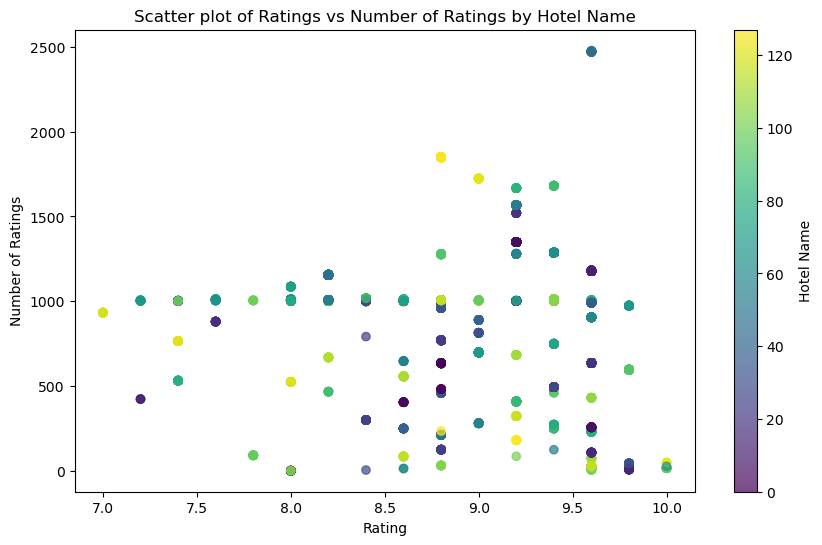

In [103]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(clean_df['hotel_rating'], clean_df['Number_review'], c=pd.Categorical(clean_df['hotel_name']).codes, cmap='viridis', alpha=0.7)

plt.colorbar(scatter , label='Hotel Name')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.title('Scatter plot of Ratings vs Number of Ratings by Hotel Name')
plt.show()

In [ ]:
clean_df.info()
# Will not handle the 500+ rows of NaN values in hotel_rating column because my model XGBoost will handle it for me. 
# I find dropping it or filling it with mean values to be ineffective because 
# 1. we want as many data as possible (this data is imbalanced and so we need to address that first)
# 2. Average is not the right approach as some hotels might have really high or low ratings. merely filling in with average can lead to bad predections. 


# Test handling data

In [5]:
drop = clean_df[clean_df.duplicated(subset=['hotel_name', 'start_date'], keep = "first")].index.to_list()
df1 = clean_df.drop(axis = 0, index = drop)
dict = {"2.0": 9.5, "1.0": 8.5, "3.0": 9, "0.0": 8.0, "4.0": 7.5, "5.0": np.nan}
df1['hotel_rating'] = df1['hotel_rating'].fillna(df1['hotel_review'].astype(str).map(dict))# fill in based on hotel_review

# value_counts = df1['hotel_name'].value_counts()
# rare_hotel_class = value_counts[value_counts == 1].index
# df1 = df1[~df1['hotel_name'].isin(rare_hotel_class)]
df1


,hotel_name,hotel_price,hotel_city,hotel_rating,hotel_review,Number_review,start_date,end_date,Breakfast,Pool,Hottub,Per_Night_Fee,Kitchen,Washer_Dryer,month,month_sin,month_cos,day_of_week
0,107,757.0,9,8.0,0.0,300.0,2024-09-01,2024-09-03,1,1,1,332.0,1,1,9,-1.000000,-1.836970e-16,6
1,313,509.0,2,8.5,1.0,557.0,2024-09-01,2024-09-03,1,0,1,219.0,1,1,9,-1.000000,-1.836970e-16,6
2,57,759.0,9,9.6,2.0,1179.0,2024-09-01,2024-09-03,0,0,0,333.0,1,1,9,-1.000000,-1.836970e-16,6
3,169,698.0,9,9.4,2.0,1287.0,2024-09-01,2024-09-03,0,0,1,306.0,1,1,9,-1.000000,-1.836970e-16,6
4,347,762.0,9,9.4,2.0,1003.0,2024-09-01,2024-09-03,0,0,1,334.0,1,1,9,-1.000000,-1.836970e-16,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10045,115,408.0,7,9.6,2.0,25.0,2025-08-29,2025-08-31,1,1,1,204.0,0,0,8,-0.866025,-5.000000e-01,4
10046,21,775.0,9,8.8,1.0,636.0,2025-08-29,2025-08-31,1,1,1,340.0,1,1,8,-0.866025,-5.000000e-01,4
10047,305,1045.0,9,9.4,2.0,1002.0,2025-08-29,2025-08-31,0,1,1,458.0,1,1,8,-0.866025,-5.000000e-01,4
10048,218,910.0,7,10.0,2.0,104.0,2025-08-29,2025-08-31,1,1,1,414.0,0,0,8,-0.866025,-5.000000e-01,4


In [10]:
test_df = df.copy()
test_df['hotel_rating'] = pd.to_numeric(test_df['hotel_rating'], errors = 'coerce')
drop1 = test_df[test_df.duplicated(subset=['hotel_name', 'start_date'], keep = "first")].index.to_list()
test_df = test_df.drop(axis = 0, index = drop1)
dict1= {"Exceptional": 9.5, "Excellent": 8.5, "Wonderful": 9, "Very Good": 8.0, "Good": 7.5, "No review": np.nan}
test_df['hotel_rating'] = test_df['hotel_rating'].fillna(test_df['hotel_review'].astype(str).map(dict1))# fill in based on hotel_review

# value_counts1 = test_df['hotel_name'].value_counts()
# rare_hotel_class1 = value_counts1[value_counts1 == 1].index
# test_df = test_df[~test_df['hotel_name'].isin(rare_hotel_class1)]
test_df

,hotel_name,hotel_price,hotel_city,hotel_rating,hotel_review,Number_review,start_date,end_date,Breakfast,Pool,Hottub,Per_Night_Fee,Kitchen,Washer_Dryer
0,"Drift Santa Barbara, a Member of Design Hotels",757,Santa Barbara,8.0,Very Good,300 reviews,2024-09-01,2024-09-03,NaN,NaN,NaN,$332 per night,NaN,NaN
1,"The Leta Santa Barbara Goleta, Tapestry Collec...",509,Goleta,8.5,Excellent,557 reviews,2024-09-01,2024-09-03,NaN,Pool,NaN,$219 per night,NaN,NaN
2,"Brisas del Mar, Inn at the Beach",759,Santa Barbara,9.6,Exceptional,"1,179 reviews",2024-09-01,2024-09-03,Breakfast,Pool,Hot tub,$333 per night,NaN,NaN
3,Lavender Inn by the Sea,698,Santa Barbara,9.4,Exceptional,"1,287 reviews",2024-09-01,2024-09-03,Breakfast,Pool,NaN,$306 per night,NaN,NaN
4,"West Beach Inn, a Coast Hotel",762,Santa Barbara,9.4,Exceptional,"1,003 reviews",2024-09-01,2024-09-03,Breakfast,Pool,NaN,$334 per night,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10045,Fabulous Studio/Suite With Private Entrance,408,Entire apartment,9.6,Exceptional,25 reviews,2025-08-29,2025-08-31,NaN,NaN,NaN,$204 per night,Kitchen,Washer and dryer
10046,Agave Inn,775,Santa Barbara,8.8,Excellent,636 reviews,2025-08-29,2025-08-31,NaN,NaN,NaN,$340 per night,NaN,NaN
10047,The Eagle Inn,1045,Santa Barbara,9.4,Exceptional,"1,002 reviews",2025-08-29,2025-08-31,Breakfast,NaN,NaN,$458 per night,NaN,NaN
10048,"Ocean, Sunset, Mountain Views, Private Deck: V...",910,Entire apartment,10.0,Exceptional,104 reviews,2025-08-29,2025-08-31,NaN,NaN,NaN,$414 per night,Kitchen,Washer and dryer


In [11]:
Value_counts = test_df['hotel_name'].value_counts()

for hotel__name, count in Value_counts.items():
    print(f"{hotel__name}: {count}")

Hotel Milo Santa Barbara: 333
Motel 6 Santa Barbara, CA - Beach: 331
Avania Inn of Santa Barbara: 330
West Beach Inn, a Coast Hotel: 325
Sandpiper Lodge: 288
Riviera Beach House: 269
Drift Santa Barbara, a Member of Design Hotels: 249
Hyatt Place Santa Barbara: 246
Best Western Plus Santa Barbara: 241
Ramada by Wyndham Santa Barbara: 208
Hotel Californian: 207
Inn By The Harbor: 202
Mason Beach Inn: 200
Lavender Inn by the Sea: 198
The Eagle Inn: 170
El Encanto, A Belmond Hotel, Santa Barbara: 170
Brisas del Mar, Inn at the Beach: 168
Residence Inn by Marriott Santa Barbara Goleta: 166
La Playa Inn: 155
Ojai Valley Inn: 152
Hotel Santa Barbara: 152
The Franciscan Hotel: 143
Mar Monte Hotel, in The Unbound Collection by Hyatt: 137
The Upham Hotel: 125
Harbor View Inn: 112
Wine Valley Inn: 99
The Inn at Mattei's Tavern: 95
Simpson House Inn: 93
Cheshire Cat Inn & Cottages: 79
Montecito Inn: 77
Courtyard Santa Barbara Goleta: 72
Harbor House Inn: 62
Hilton Santa Barbara Beachfront Resort:

In [10]:
hotel_list = [
    "Hotel Milo Santa Barbara", "Motel 6 Santa Barbara, CA - Beach", "Avania Inn of Santa Barbara", 
    "West Beach Inn, a Coast Hotel", "Sandpiper Lodge", "Riviera Beach House", 
    "Drift Santa Barbara, a Member of Design Hotels", "Hyatt Place Santa Barbara", 
    "Best Western Plus Santa Barbara", "Ramada by Wyndham Santa Barbara", "Hotel Californian", 
    "Inn By The Harbor", "Mason Beach Inn", "Lavender Inn by the Sea", "The Eagle Inn", 
    "El Encanto, A Belmond Hotel, Santa Barbara", "Brisas del Mar, Inn at the Beach", 
    "Residence Inn by Marriott Santa Barbara Goleta", "La Playa Inn", "Ojai Valley Inn", 
    "Hotel Santa Barbara", "The Franciscan Hotel", "Mar Monte Hotel, in The Unbound Collection by Hyatt", 
    "The Upham Hotel", "Harbor View Inn", "Wine Valley Inn", "The Inn at Mattei's Tavern", 
    "Simpson House Inn", "Cheshire Cat Inn & Cottages", "Montecito Inn", 
    "Courtyard Santa Barbara Goleta", "Harbor House Inn", "Hilton Santa Barbara Beachfront Resort", 
    "Best Western Plus Pepper Tree Inn", "Marina Beach Motel", "Bath Street Inn", "Lemon Tree Inn", 
    "Castillo Inn at the Beach", "Cliff House Inn On The Ocean", "Casa Jardin", "Casa De La Vina", 
    "Rosewood Miramar Beach", "New Haven Inn", "Agave Inn", "Pacific Crest Hotel Santa Barbara", 
    "The Inn at East Beach", "Hamlet Inn", "Kimpton Canary Hotel, an IHG Hotel", 
    "The Leta Santa Barbara Goleta, Tapestry Collection by Hilton", "Sideways Inn", 
    "Hotel Corque", "Vinland Hotel and Lounge", "Palihouse Santa Barbara", "Oakridge Inn", 
    "Extended Stay America Suites Santa Barbara Calle Real", "Secret Garden Inn and Cottages", 
    "Santa Barbara Mission Studio", "Santa Ynez Valley Marriott", "Motel 6 Goleta, CA - Santa Barbara", 
    "King Frederik Inn", "The Winston Solvang", "Hotel Hygge", "Best Western Plus South Coast Inn", 
    "The M Solvang", "Holiday Inn Express Hotel & Suites Carpinteria", "The Ritz-Carlton Bacara, Santa Barbara", 
    "Hilton Garden Inn Santa Barbara / Goleta", "Motel 6 Carpinteria, CA - Santa Barbara - South", 
    "Motel 6 Santa Barbara, CA - State Street", 
    "Moxy Santa Barbara", "Inn on Summer Hill", "Quality Inn Buellton - Solvang", 
    "ForFriends Inn Bed and Breakfast", "Flying Flags RV Resort & Campground", 
    "Orange Tree Inn", "Coast Village Inn - Santa Barbara", 
    "Ojai Retreat & Inn", 
    "Villa Rosa Inn", 
    "The Hadsten Solvang, Tapestry Collection by Hilton", "Royal Copenhagen Inn", 
    "Hampton Inn Santa Barbara/Goleta", 
    "Relax in the heart of Montecito", "Oasis Inn & Suites", "Solvang Inn and Cottages", 
    "Courtyard by Marriott Santa Barbara Downtown", "Beachside Inn", 
    "Hotel Virginia Santa Barbara, Tapestry Collection by Hilton", "Pea Soup Andersen's Inn", 
    "Hideaway Santa Barbara, A Kirkwood Collection Property", 
    "Best Western Plus Carpinteria Inn", 
    "Ocean, Sunset, Mountain Views, Private Deck: Villa Floresco: Tuscan-like getaway", 
    "The Ballard Inn, A Kirkwood Collection Hotel", 
    "The Steward, Santa Barbara, a Tribute Portfolio Hotel", "Motel 6 Carpinteria, CA - Santa Barbara - North", 
    "The Landsby", "Rancho Oso RV & Camping Resort", 
    "Chantico Inn", "Summerland Guest Cottage just steps to downtown and the beach! Pet Friendly", 
    "Viking Inn", "Casita Eco-Glamping", 
    "Hilton Garden Inn Lompoc", "AGAVE INN HOTEL", 
    "The perfect Los Olivos Guest House", 
    "Rose Garden Inn", 
    "The Presidio", "Kronborg Inn", 
    "Motel 6 Buellton, CA - Solvang Area", "The Genevieve", "Ala Mar by the Sea", 
    "Town and Country Inn", 
    "Holiday Inn Express Lompoc, an IHG Hotel",
    "Lompoc Valley Inn and Suites", "Atterdag Inn", 
    "WorldMark Solvang", 
    "Sandyland Beach Studio Carpinteria", 
    "Chumash Casino Resort", 
    "Haley Hotel", "Embassy Suites by Hilton Lompoc Central Coast", 
    "Hampton Inn & Suites Buellton/Santa Ynez Valley", "Blue Door Bungalow.", 
    "Papa Dux - A Playful Urban Penthouse", "Tide Pool Villas", 
    "Copenhagen Airy Apartment", "The Wine Valley Cottage - est. 2011", "Santa Barbara Inn", 
    "Mirabelle Inn and Restaurant", "Inn at Highway 1", "Sunset Motel", 
    "Casa Del Sol", 
    "Blue Iguana Inn", "The Inn at Zaca Creek",
    "Perfect Resort in Charming Solvang California", "The De La Vina Inn", 
    "La Petite Maison in Santa Ynez", 
    "Mama Dux - A Sumptuous Urban Sanctuary", "The Los Alamos Roadhouse",
    "Los Aguajes",
    "The 3 Dux", "Svendsgaard's Danish Lodge Americas Best Value Inn", 
    "Summerland Ocean View no. 3",
    "Alamo Motel", "Charming Santa Ynez farmhouse", "San Marcos Motel", "The COOP - SYV", 
    "The Oakley at the Los Alamos Mercantile",  
    "Blue Sands Inn, A Kirkwood Collection Hotel", 
    "Villa Verde - Luxurious Ocean and Mountain View Villa", 
    "Shoreline Escape", 
    "La Cabana Paradise Across Street To The Beach", 
    "Palmoro House",
    "Hidden Valley Retreat - Near Beach + Dtwn", 
    "HYGGE TOWER APARTMENT", "Rustic Elegance in Los Olivos", 
    "WorldMark Solvang - 2 Bedroom Twin Accessible", 
    "The Santa Barbara Whale House", 
    "Skyview Hotel - 21 & Over Pool", 
    "The Rose Mar Four Bedroom Villa Near Ocean", 
    "Hotel Ynez", 
    "Budget Inn Lompoc", "Downtown Hideaway with Patio", 
    "Ojai Serenity Retreat, a haven of tranquility for both couples and families.", 
    "Merkantile-4 Solvang / Luxury Lofts near downtown", 
    "Coffee House 1906 Craftsman Cottage, 2 blks State St, 5 Amtrak PET!", 
    "Chic & Sophisticated Studio with Panoramic Views & Privacy (yard, pet friendly!)", 
    "Lotus of Lompoc - A Great Hospitality Inn", 
    "The Craft House Inn",
    "O'cairns Inn & Suites", 
    "Comfort Inn & Suites Ventura Beach", "Hilton Garden Inn Oxnard/Camarillo", 
    "Holiday Inn Express Hotel & Suites Ventura, an IHG Hotel",
    "Fess Parker Wine Country Inn", 
    "Merkantile-5 Solvang / Luxury Lofts near downtown", 
    "Private Ranch Retreat", 
    "La Mesa House: large modern home", 
    "WorldMark Solvang - 2 Bedroom", 
    "Ojai Rancho Inn", "Casa Ojai Inn", 
    "Hummingbird Inn of Ojai","The Capri Hotel", 
    "Viking Motel", "Crystal Lodge Motel", "White Caps Motel", 
    "Hidden Cove By The Sea", "Heavenly Escape By The Sea", 
    "Sunset Haven By The Sea", "Travelers Beach Inn", 
    "WorldMark Solvang - 2 Bedroom Penthouse", 
    "WorldMark Solvang - 2 Bedroom Twin", "West Beach Treehouse", 
    "WorldMark Solvang - Studio", "WorldMark Solvang - 2 Bedroom Queen", 
    "WorldMark Solvang - 2 Bedroom Accessible", "WorldMark Solvang - 1 Bedroom Accessible", 
    "3809S Beach Blessing", 
    "Boutique Comfort at Inn at HWY1", 
    "Montecito retreat - minutes to Butterfly Beach, Lower Village, & downtown", 
    "Escape the City.",
    "Motel 6 Lompoc, CA", "Inn of Lompoc",
    "Santa Ynez Vineyard Retreat! The Guest Cottage at Starfall Ranch", 
    "Queen-Sized Room, Lounge Area with Mountain Views", "Wyatt Earp at the Los Alamos Mercantile", 
    "WorldMark Solvang - 1 Bedroom",
    "Beautiful Rose Cottage In Wine Country", 
    "Boutique Hotel Double Queen Patio Room", "Sweet Queen Retreat in Downtown Los Olivos.", "Farmhouse-chic Carpinteria Cottage w/ Pool Access", 
    "Anavo Farm's Stylish Sheep Retreat", "Ojai Mountain View Country Retreat"]





In [11]:
test = df.copy()
test = test[test['hotel_name'].isin(hotel_list)]
len(test['hotel_name'].unique())

207

In [12]:
rename_dict = {
    "Hotel Milo Santa Barbara": "Hotel Milo Santa Barbara",
    "Motel 6 Santa Barbara, CA - Beach": "Motel 6 Santa Barbara",
    "Avania Inn of Santa Barbara": "Avania Inn",
    "West Beach Inn, a Coast Hotel": "West Beach Inn",
    "Sandpiper Lodge": "Sandpiper Lodge",
    "Riviera Beach House": "Riviera Beach House",
    "Drift Santa Barbara, a Member of Design Hotels": "Drift Santa Barbara",
    "Hyatt Place Santa Barbara": "Hyatt Place Santa Barbara",
    "Best Western Plus Santa Barbara": "Best Western Plus Santa Barbara",
    "Ramada by Wyndham Santa Barbara": "Ramada Santa Barbara",
    "Hotel Californian": "Hotel Californian",
    "Inn By The Harbor": "Inn By The Harbor",
    "Mason Beach Inn": "Mason Beach Inn",
    "Lavender Inn by the Sea": "Lavender Inn",
    "The Eagle Inn": "The Eagle Inn",
    "El Encanto, A Belmond Hotel, Santa Barbara": "El Encanto Hotel",
    "Brisas del Mar, Inn at the Beach": "Brisas del Mar",
    "Residence Inn by Marriott Santa Barbara Goleta": "Residence Inn Goleta",
    "La Playa Inn": "La Playa Inn",
    "Ojai Valley Inn": "Ojai Valley Inn",
    "Hotel Santa Barbara": "Hotel Santa Barbara",
    "The Franciscan Hotel": "The Franciscan Hotel",
    "Mar Monte Hotel, in The Unbound Collection by Hyatt": "Mar Monte Hotel",
    "The Upham Hotel": "The Upham Hotel",
    "Harbor View Inn": "Harbor View Inn",
    "Wine Valley Inn": "Wine Valley Inn",
    "The Inn at Mattei's Tavern": "Inn at Mattei's Tavern",
    "Simpson House Inn": "Simpson House Inn",
    "Cheshire Cat Inn & Cottages": "Cheshire Cat Inn & Cottages",
    "Montecito Inn": "Montecito Inn",
    "Courtyard Santa Barbara Goleta": "Courtyard Goleta",
    "Harbor House Inn": "Harbor House Inn",
    "Hilton Santa Barbara Beachfront Resort": "Hilton Santa Barbara Beachfront Resort",
    "Best Western Plus Pepper Tree Inn": "Best Western Pepper Tree Inn",
    "Marina Beach Motel": "Marina Beach Motel",
    "Bath Street Inn": "Bath Street Inn",
    "Lemon Tree Inn": "Lemon Tree Inn",
    "Castillo Inn at the Beach": "Castillo Inn",
    "Cliff House Inn On The Ocean": "Cliff House Inn",
    "Casa Jardin": "Casa Jardin",
    "Casa De La Vina": "Casa De La Vina",
    "Rosewood Miramar Beach": "Rosewood Miramar",
    "New Haven Inn": "New Haven Inn",
    "Agave Inn": "Agave Inn",
    "Pacific Crest Hotel Santa Barbara": "Pacific Crest Hotel",
    "The Inn at East Beach": "Inn at East Beach",
    "Hamlet Inn": "Hamlet Inn",
    "Kimpton Canary Hotel, an IHG Hotel": "Kimpton Canary Hotel",
    "The Leta Santa Barbara Goleta, Tapestry Collection by Hilton": "The Leta Santa Barbara",
    "Sideways Inn": "Sideways Inn",
    "Hotel Corque": "Hotel Corque",
    "Vinland Hotel and Lounge": "Vinland Hotel",
    "Palihouse Santa Barbara": "Palihouse Santa Barbara",
    "Oakridge Inn": "Oakridge Inn",
    "Extended Stay America Suites Santa Barbara Calle Real": "Extended Stay America Santa Barbara",
    "Secret Garden Inn and Cottages": "Secret Garden Inn",
    "Santa Barbara Mission Studio": "Santa Barbara Mission Studio",
    "Santa Ynez Valley Marriott": "Santa Ynez Valley Marriott",
    "Motel 6 Goleta, CA - Santa Barbara": "Motel 6 Goleta",
    "King Frederik Inn": "King Frederik Inn",
    "The Winston Solvang": "The Winston Solvang",
    "Hotel Hygge": "Hotel Hygge",
    "Best Western Plus South Coast Inn": "Best Western South Coast Inn",
    "The M Solvang": "The M Solvang",
    "Holiday Inn Express Hotel & Suites Carpinteria": "Holiday Inn Express Carpinteria",
    "The Ritz-Carlton Bacara, Santa Barbara": "The Ritz-Carlton Bacara",
    "Hilton Garden Inn Santa Barbara / Goleta": "Hilton Garden Inn Goleta",
    "Motel 6 Carpinteria, CA - Santa Barbara - South": "Motel 6 Carpinteria",
    "Motel 6 Santa Barbara, CA - State Street": "Motel 6 Santa Barbara",
    "Moxy Santa Barbara": "Moxy Santa Barbara",
    "Inn on Summer Hill": "Inn on Summer Hill",
    "Quality Inn Buellton - Solvang": "Quality Inn Buellton",
    "ForFriends Inn Bed and Breakfast": "ForFriends Inn",
    "Flying Flags RV Resort & Campground": "Flying Flags Resort",
    "Orange Tree Inn": "Orange Tree Inn",
    "Coast Village Inn - Santa Barbara": "Coast Village Inn",
    "Ojai Retreat & Inn": "Ojai Retreat Inn",
    "Villa Rosa Inn": "Villa Rosa Inn",
    "The Hadsten Solvang, Tapestry Collection by Hilton": "The Hadsten Solvang",
    "Royal Copenhagen Inn": "Royal Copenhagen Inn",
    "Hampton Inn Santa Barbara/Goleta": "Hampton Inn Goleta",
    "Oasis Inn & Suites": "Oasis Inn & Suites",
    "Solvang Inn and Cottages": "Solvang Inn and Cottages",
    "Courtyard by Marriott Santa Barbara Downtown": "Courtyard by Marriott Santa Barbara Downtown",
    "Beachside Inn": "Beachside Inn",
    "Hotel Virginia Santa Barbara, Tapestry Collection by Hilton": "Hotel Virginia Santa Barbara Hilton",
    "Pea Soup Andersen's Inn": "Pea Soup Andersen's Inn",
    "Hideaway Santa Barbara, A Kirkwood Collection Property": "Hideaway Santa Barbara",
    "Best Western Plus Carpinteria Inn": "Best Western Carpinteria Inn",
    "The Ballard Inn, A Kirkwood Collection Hotel": "The Ballard Inn",
    "The Steward, Santa Barbara, a Tribute Portfolio Hotel": "The Steward Santa Barbara",
    "The Landsby": "The Landsby",
    "Rancho Oso RV & Camping Resort": "Rancho Oso Resort",
    "Chantico Inn": "Chantico Inn",
    "Viking Inn": "Viking Inn",
    "Hilton Garden Inn Lompoc": "Hilton Garden Inn Lompoc",
    "Rose Garden Inn": "Rose Garden Inn",
    "The Presidio": "The Presidio",
    "Kronborg Inn": "Kronborg Inn",
    "Motel 6 Buellton, CA - Solvang Area": "Motel 6 Buellton",
    "The Genevieve": "The Genevieve",
    "Ala Mar by the Sea": "Ala Mar by the Sea",
    "Town and Country Inn": "Town and Country Inn",
    "Holiday Inn Express Lompoc, an IHG Hotel": "Holiday Inn Express Lompoc",
    "Lompoc Valley Inn and Suites": "Lompoc Valley Inn",
    "Atterdag Inn": "Atterdag Inn",
    "WorldMark Solvang": "WorldMark Solvang",
    "Chumash Casino Resort": "Chumash Casino Resort",
    "Haley Hotel": "Haley Hotel",
    "Embassy Suites by Hilton Lompoc Central Coast": "Embassy Suites Lompoc",
    "Hampton Inn & Suites Buellton/Santa Ynez Valley": "Hampton Inn Buellton",
    "Santa Barbara Inn": "Santa Barbara Inn",
    "Mirabelle Inn and Restaurant": "Mirabelle Inn",
    "Inn at Highway 1": "Inn at Highway 1",
    "Sunset Motel": "Sunset Motel",
    "Casa Del Sol": "Casa Del Sol",
    "Blue Iguana Inn": "Blue Iguana Inn",
    "The Inn at Zaca Creek": "Inn at Zaca Creek",
    "The De La Vina Inn": "The De La Vina Inn",
    "La Petite Maison in Santa Ynez": "La Petite Maison",
    "Mama Dux - A Sumptuous Urban Sanctuary": "Mama Dux",
    "The Los Alamos Roadhouse": "Los Alamos Roadhouse",
    "The 3 Dux": "The 3 Dux",
    "Svendsgaard's Danish Lodge Americas Best Value Inn": "Svendsgaard's Danish Lodge",
    "Alamo Motel": "Alamo Motel",
    "San Marcos Motel": "San Marcos Motel",
    "The COOP - SYV": "The COOP",
    "The Oakley at the Los Alamos Mercantile": "The Oakley",
    "Blue Sands Inn, A Kirkwood Collection Hotel": "Blue Sands Inn",
    "Villa Verde - Luxurious Ocean and Mountain View Villa": "Villa Verde",
    "Shoreline Escape": "Shoreline Escape",
    "La Cabana Paradise Across Street To The Beach": "La Cabana Paradise",
    "Palmoro House": "Palmoro House",
    "Hidden Valley Retreat - Near Beach + Dtwn": "Hidden Valley Retreat",
        "HYGGE TOWER APARTMENT": "HYGGE Tower",
    "Rustic Elegance in Los Olivos": "Rustic Elegance",
    "WorldMark Solvang - 2 Bedroom Twin Accessible": "WorldMark Solvang",
    "The Santa Barbara Whale House": "Whale House",
    "Skyview Hotel - 21 & Over Pool": "Skyview Hotel",
    "The Rose Mar Four Bedroom Villa Near Ocean": "The Rose Mar Villa",
    "Hotel Ynez": "Hotel Ynez",
    "Budget Inn Lompoc": "Budget Inn",
    "Downtown Hideaway with Patio": "Downtown Hideaway",
    "Ojai Serenity Retreat, a haven of tranquility for both couples and families.": "Ojai Serenity Retreat",
    "Merkantile-4 Solvang / Luxury Lofts near downtown": "Merkantile Solvang",
    "Coffee House 1906 Craftsman Cottage, 2 blks State St, 5 Amtrak PET!": "Coffee House 1906",
    "Chic & Sophisticated Studio with Panoramic Views & Privacy (yard, pet friendly!)": "Chic & Sophisticated Studio",
    "Lotus of Lompoc - A Great Hospitality Inn": "Lotus of Lompoc",
    "The Craft House Inn": "The Craft House Inn",
    "O'cairns Inn & Suites": "O'cairns Inn",
    "Comfort Inn & Suites Ventura Beach": "Comfort Inn Ventura Beach",
    "Hilton Garden Inn Oxnard/Camarillo": "Hilton Garden Inn Oxnard",
    "Holiday Inn Express Hotel & Suites Ventura, an IHG Hotel": "Holiday Inn Express Ventura",
    "Fess Parker Wine Country Inn": "Fess Parker Inn",
    "Merkantile-5 Solvang / Luxury Lofts near downtown": "Merkantile Solvang",
    "Private Ranch Retreat": "Private Ranch Retreat",
    "La Mesa House: large modern home": "La Mesa House",
    "WorldMark Solvang - 2 Bedroom": "WorldMark Solvang",
    "Ojai Rancho Inn": "Ojai Rancho Inn",
    "Casa Ojai Inn": "Casa Ojai Inn",
    "Hummingbird Inn of Ojai": "Hummingbird Inn",
    "The Capri Hotel": "The Capri Hotel",
    "Viking Motel": "Viking Motel",
    "Crystal Lodge Motel": "Crystal Lodge Motel",
    "White Caps Motel": "White Caps Motel",
    "Hidden Cove By The Sea": "Hidden Cove",
    "Heavenly Escape By The Sea": "Heavenly Escape",
    "Sunset Haven By The Sea": "Sunset Haven",
    "Travelers Beach Inn": "Travelers Beach Inn",
    "WorldMark Solvang - 2 Bedroom Penthouse": "WorldMark Solvang",
    "West Beach Treehouse": "West Beach Treehouse",
    "WorldMark Solvang - Studio": "WorldMark Solvang",
    "Boutique Comfort at Inn at HWY1": "Inn at HWY1",
    "Montecito retreat - minutes to Butterfly Beach, Lower Village, & downtown": "Montecito Retreat",
    "Escape the City.": "Escape the City",
    "Motel 6 Lompoc, CA": "Motel 6 Lompoc",
    "Inn of Lompoc": "Inn of Lompoc",
    "Santa Ynez Vineyard Retreat! The Guest Cottage at Starfall Ranch": "Santa Ynez Vineyard Retreat",
    "Queen-Sized Room, Lounge Area with Mountain Views": "Queen-Sized Room",
    "Wyatt Earp at the Los Alamos Mercantile": "Wyatt Earp Los Alamos",
    "WorldMark Solvang - 1 Bedroom": "WorldMark Solvang",
    "Beautiful Rose Cottage In Wine Country": "Rose Cottage Wine Country",
    "Boutique Hotel Double Queen Patio Room": "Boutique Hotel",
    "Sweet Queen Retreat in Downtown Los Olivos.": "Sweet Queen Retreat",
    "Farmhouse-chic Carpinteria Cottage w/ Pool Access": "Farmhouse-chic Cottage",
    "Anavo Farm's Stylish Sheep Retreat": "Anavo Farm Retreat",
    "Ojai Mountain View Country Retreat": "Ojai Mountain View Retreat"
}

test['hotel_name'] = test['hotel_name'].replace(rename_dict)


In [15]:
df2 = test.copy()


label_encoder = LabelEncoder()
# df2['Breakfast'] = label_encoder.fit_transform(test['Breakfast'])
# df2['Pool'] = label_encoder.fit_transform(test['Pool'])
# df2['Hottub'] = label_encoder.fit_transform(test['Hottub'])
# df2['Kitchen'] = label_encoder.fit_transform(test['Kitchen'])
# df2['Washer_Dryer'] = label_encoder.fit_transform(test['Washer_Dryer'])
df2 = pd.get_dummies(df2, columns=['Breakfast', "Pool", "Hottub", "Kitchen", "Washer_Dryer"], drop_first=False)

df2['Number_review'] = df2['Number_review'].str.replace("\D", '', regex = True)
df2['Number_review'] = pd.to_numeric(df2['Number_review'], errors = 'coerce')

# clean_df = clean_df[clean_df['hotel_review'] != 'No review']
# list(clean_df['hotel_review'].unique()) -> use this for the category list
oe = OrdinalEncoder(categories=[["No review",'Good', 'Very Good', 'Wonderful', 'Excellent', 'Exceptional']])
df2['hotel_review'] = oe.fit_transform(df2[['hotel_review']])

df2['month'] = df2['start_date'].dt.month
df2['day'] = clean_df['start_date'].dt.day

df2['month_sin'] = np.sin(2 * np.pi * df2['month']/12)
df2['day_sin'] = np.sin(2 * np.pi * df2['day']/31)

df2['month_cos'] = np.cos(2 * np.pi * df2['month']/12)
df2['day_cos'] = np.cos(2 * np.pi * df2['day']/31)

df2['day_of_week'] = df2['start_date'].dt.dayofweek

# clean_df = clean_df.drop(['start_date', 'end_date'], axis = 1)

# clean_df['hotel_price'] = clean_df['hotel_price'].str.replace("\D", '', regex = True)
df2['hotel_price'] = pd.to_numeric(df2['hotel_price'], errors = 'coerce')
df2['Per_Night_Fee'] = df2['Per_Night_Fee'].str.replace("\D", '', regex = True)
df2['Per_Night_Fee'] = pd.to_numeric(df2['Per_Night_Fee'], errors = 'coerce')


df2['hotel_rating'] = pd.to_numeric(df2['hotel_rating'], errors = 'coerce')

df2['hotel_name'] = label_encoder.fit_transform(df2['hotel_name'])

# clean_df['hotel_city'].unique() -> use this to extract all city name
pattern = r'(Santa Barbara|Goleta|Solvang|Los Olivos|Buellton|Montecito|Carpinteria|Santa Ynez|Los Alamos|Lompoc|Ojai|Ventura)'
df2['hotel_city'] = df2['hotel_city'].str.extract(pattern, flags = re.IGNORECASE)
df2['hotel_city'] = df2['hotel_city'].fillna("No City Name")
df2 = pd.get_dummies(df2, columns=['hotel_city'], drop_first=False)
# clean_df = clean_df[clean_df['hotel_city'] != "No City Name"]
#df2['hotel_city'] = label_encoder.fit_transform(df2['hotel_city'])

#df2 = pd.concat([df2, dummies], axis = 1)
#df2 = df2.drop(['Breakfast', 'Pool', 'Hottub', 'Kitchen', 'Washer_Dryer'], axis = 1)
# df['day'] = df['date_column'].dt.day
# clean_df['hotel_review'] = 
df2


,hotel_name,hotel_price,hotel_rating,hotel_review,Number_review,start_date,end_date,Per_Night_Fee,Breakfast_Breakfast,Pool_Pool,...,hotel_city_Lompoc,hotel_city_Los Alamos,hotel_city_Los Olivos,hotel_city_Montecito,hotel_city_No City Name,hotel_city_Ojai,hotel_city_Santa Barbara,hotel_city_Santa Ynez,hotel_city_Solvang,hotel_city_Ventura
0,40,757,NaN,2.0,300.0,2024-09-01,2024-09-03,332,0,0,...,0,0,0,0,0,0,1,0,0,0
1,170,509,NaN,4.0,557.0,2024-09-01,2024-09-03,219,0,1,...,0,0,0,0,0,0,0,0,0,0
2,18,759,9.6,5.0,1179.0,2024-09-01,2024-09-03,333,1,1,...,0,0,0,0,0,0,1,0,0,0
3,91,698,9.4,5.0,1287.0,2024-09-01,2024-09-03,306,1,1,...,0,0,0,0,0,0,1,0,0,0
4,189,762,9.4,5.0,1003.0,2024-09-01,2024-09-03,334,1,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10044,77,1049,8.2,2.0,1004.0,2025-08-29,2025-08-31,460,0,1,...,0,0,0,0,1,0,0,0,0,0
10046,2,775,8.8,4.0,636.0,2025-08-29,2025-08-31,340,0,0,...,0,0,0,0,0,0,1,0,0,0
10047,165,1045,9.4,5.0,1002.0,2025-08-29,2025-08-31,458,1,0,...,0,0,0,0,0,0,1,0,0,0
10048,116,910,10.0,5.0,104.0,2025-08-29,2025-08-31,414,0,0,...,0,0,0,0,1,0,0,0,0,0


In [16]:
drop = df2[df2.duplicated(subset=['hotel_name', 'start_date'], keep = "first")].index.to_list()
df2 = df2.drop(axis = 0, index = drop)
dict = {"5.0": 9.5, "4.0": 9.0, "3.0": 8.5, "2.0": 8.0, "1.0": 7.5, "0.0": np.nan}
df2['hotel_rating'] = df2['hotel_rating'].fillna(df2['hotel_review'].astype(str).map(dict))# fill in based on hotel_review

# value_counts = df1['hotel_name'].value_counts()
# rare_hotel_class = value_counts[value_counts == 1].index
# df1 = df1[~df1['hotel_name'].isin(rare_hotel_class)]
df2

,hotel_name,hotel_price,hotel_rating,hotel_review,Number_review,start_date,end_date,Per_Night_Fee,Breakfast_Breakfast,Pool_Pool,...,hotel_city_Lompoc,hotel_city_Los Alamos,hotel_city_Los Olivos,hotel_city_Montecito,hotel_city_No City Name,hotel_city_Ojai,hotel_city_Santa Barbara,hotel_city_Santa Ynez,hotel_city_Solvang,hotel_city_Ventura
0,40,757,8.0,2.0,300.0,2024-09-01,2024-09-03,332,0,0,...,0,0,0,0,0,0,1,0,0,0
1,170,509,9.0,4.0,557.0,2024-09-01,2024-09-03,219,0,1,...,0,0,0,0,0,0,0,0,0,0
2,18,759,9.6,5.0,1179.0,2024-09-01,2024-09-03,333,1,1,...,0,0,0,0,0,0,1,0,0,0
3,91,698,9.4,5.0,1287.0,2024-09-01,2024-09-03,306,1,1,...,0,0,0,0,0,0,1,0,0,0
4,189,762,9.4,5.0,1003.0,2024-09-01,2024-09-03,334,1,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10044,77,1049,8.2,2.0,1004.0,2025-08-29,2025-08-31,460,0,1,...,0,0,0,0,1,0,0,0,0,0
10046,2,775,8.8,4.0,636.0,2025-08-29,2025-08-31,340,0,0,...,0,0,0,0,0,0,1,0,0,0
10047,165,1045,9.4,5.0,1002.0,2025-08-29,2025-08-31,458,1,0,...,0,0,0,0,0,0,1,0,0,0
10048,116,910,10.0,5.0,104.0,2025-08-29,2025-08-31,414,0,0,...,0,0,0,0,1,0,0,0,0,0


# Handle Imbalance Dataset

In [ ]:
# Make sure Data are balance
clean_df.groupby("start_date").size().sort_values(ascending = False).plot.barh() # this tells me the smallest number of rows
# This graph is just to inform us about the imbalance dataset, and issue that we have to address. 

In [ ]:
clean_df.groupby("start_date").size().nlargest(20)

In [ ]:
# clean_df.groupby("hotel_name").size().nsmallest(20)
clean_df['hotel_name'].value_counts()

I use this as my undersampling approach because:
1. I scrape it direcly from the webpage, so it resembles the first 20 hotels that I scrape, just like all other hotels. 
2. It reduces some date's overrepresentation, dates that have over 100 rows that might dominate  the training dataset thus introducing bias for my model.
3. This way maintains the original distribution of the data that I have. 

# ML Model

## Reasons why I'm choosing XGBoost
1. I have NaN values and XGBoost itself automatically fix it
2. I have a structured/tabular data
3. Better choice for large dataset as my project can grow in size if scrape more (in the future)
4. Includes parameters that help to handle overfitting model (imbalance data)
Due to the innate nature of classifying over tens and hundreds of hotels, I decided that Random Forest and SVM might not be the most efficient ML algorithm and therefore chose Gradient Descent as my model. 
* more regularized and more scalable

https://medium.com/@bravinwasike18/dive-into-xgboost-and-scikit-learnmachine-learning-with-xgboost-and-scikit-learn-17e2cf54f3a3

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score 
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import KFold, cross_val_score
import xgboost
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN


In [8]:
X = df1.drop(['start_date', 'end_date','month', 'hotel_name'], axis=1)
y = df1['hotel_name']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 # Sed seed so results can be duplicated, use stratify to make sure to keep the same percentages of classes for the split
y_train = label_encoder.fit_transform(y_train) # Class column has to start from 0 to solve "Invalid classes inferred from unique values of `y`"

# calculate class weights based on the training data
# classes = np.unique(y_train)
# class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
# class_weight_dict = {classes[i]: class_weights[i] for i in range(len(classes))}
# sample_weights = np.array([class_weight_dict[class_] for class_ in y_train])
xgb_base_model = XGBClassifier(n_estimators = 350, base_score = 0.003, learning_rate = 0.03, random_state=42, eval_metric='logloss') #base_score: inverse of the number of classes


xgb_base_model.fit(X_train, y_train,)
base_predictions = xgb_base_model.predict(X_test)

base_predictions



array([177, 139, 104, ..., 101, 284, 243])

In [ ]:
list(base_predictions)

In [ ]:
y_test.head(30)

In [9]:
print("Accuracy of Model::",accuracy_score(y_test, base_predictions))
class_report = classification_report(y_test, base_predictions)
print(f"Classification Report:\n{class_report}")
# As we can see, our base model is a poor-performing model that barely yield any accurate result. 

Accuracy of Model:: 0.0568119139547711
Classification Report:
              precision    recall  f1-score   support

           4       0.50      1.00      0.67         1
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         0
          10       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         4
          15       1.00      0.67      0.80         6
          16       0.83      1.00      0.91         5
          21       1.00      1.00      1.00         5
          22       0.00      0.00      0.00         0
          23       1.00      1.00      1.00         2
          24       1.00      1.00      1.00         4
          25       0.50      0.80      0.62         5
          26       0.00      0.00      0.00         0
          27       0.00      0.00      0.00         0
          28       0.00      0.00      0.00         3
          29       

/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bo

In [185]:
# filter the 300+ hotels, remove those that has a weird name. Use the 6000+ data/ the filter one. After that, we need to use SMOTE or oversample 
# as it gives us more data to work with. Might need to drop a 


In [78]:
# from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
# def calc_specificity(y_actual, y_pred, thresh):
#  # calculates specificity
#  return sum((y_pred < thresh) & (y_actual == 0)) /sum(y_actual ==0)
# def print_report(y_actual, y_pred, thresh):
 
#  auc = roc_auc_score(y_actual, y_pred)
#  accuracy = accuracy_score(y_actual, (y_pred > thresh))
#  recall = recall_score(y_actual, (y_pred > thresh))
#  precision = precision_score(y_actual, (y_pred > thresh))
#  specificity = calc_specificity(y_actual, y_pred, thresh)
#  print(‘AUC:%.3f’%auc)
#  print(‘accuracy:%.3f’%accuracy)
#  print(‘recall:%.3f’%recall)
#  print(‘precision:%.3f’%precision)
#  print(‘specificity:%.3f’%specificity)
#  print(‘prevalence:%.3f’%calc_prevalence(y_actual))
#  print(‘ ‘)
#  return auc, accuracy, recall, precision, specificity



# Maybe I can predict time trends/prices instead of hotel rooms

In [43]:
X1 = df2.drop(['start_date', 'end_date','month', 'day', 'hotel_name'], axis=1)
y1 = df2['hotel_name']


X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
 # Sed seed so results can be duplicated, use stratify to make sure to keep the same percentages of classes for the split
y_train1 = label_encoder.fit_transform(y_train1) # Class column has to start from 0 to solve "Invalid classes inferred from unique values of `y`"

# calculate class weights based on the training data
# classes = np.unique(y_train)
# class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
# class_weight_dict = {classes[i]: class_weights[i] for i in range(len(classes))}
# sample_weights = np.array([class_weight_dict[class_] for class_ in y_train])
xgb_base_model1 = XGBClassifier(n_estimators = 200, base_score = 0.005, learning_rate = 0.05, random_state=42, eval_metric='mlogloss') #base_score: inverse of the number of classes


xgb_base_model1.fit(X_train1, y_train1)
base_predictions1 = xgb_base_model1.predict(X_test1)

base_predictions1



array([ 40,  20, 115, ..., 121, 141,  12])

In [42]:
#auc = roc_auc_score(y_test1, base_predictions1)
#print('AUC:%.3f'%auc)
print("Accuracy of Model::",accuracy_score(y_test1, base_predictions1))
class_report1 = classification_report(y_test1, base_predictions1)
print(f"Classification Report:\n{class_report1}")

Accuracy of Model:: 0.22085889570552147
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00         4
           4       0.67      1.00      0.80         2
           6       0.80      1.00      0.89         4
           7       1.00      1.00      1.00        72
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         6
          12       1.00      1.00      1.00        49
          13       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         3
          18       1.00      1.00      1.00        34
          19       0.50      1.00      0.67         1
          20       1.00      1.00      1.00         6
          21      

/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bo

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = xgb_base_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))


In [ ]:
kfold = KFold(n_splits=5, random_state=42,shuffle = True)

results = cross_val_score(xgb_base_model1, X_train1, y_train1, cv=kfold)

print("Accuracy: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

In [17]:
df3 = df2.copy()
df3['hotel_rating'] = df3.groupby("hotel_name")['hotel_rating'].ffill().bfill()
df3['Number_review'] = df3.groupby("hotel_name")['Number_review'].ffill().bfill()

# value_counts = df3['hotel_name'].value_counts()
# rare_hotel_class = value_counts[value_counts == 1].index
# df3 = df3[~df3['hotel_name'].isin(rare_hotel_class)]

df3 = df3.reset_index(drop=True)
df3

,hotel_name,hotel_price,hotel_rating,hotel_review,Number_review,start_date,end_date,Per_Night_Fee,Breakfast_Breakfast,Pool_Pool,...,hotel_city_Lompoc,hotel_city_Los Alamos,hotel_city_Los Olivos,hotel_city_Montecito,hotel_city_No City Name,hotel_city_Ojai,hotel_city_Santa Barbara,hotel_city_Santa Ynez,hotel_city_Solvang,hotel_city_Ventura
0,40,757,8.0,2.0,300.0,2024-09-01,2024-09-03,332,0,0,...,0,0,0,0,0,0,1,0,0,0
1,170,509,9.0,4.0,557.0,2024-09-01,2024-09-03,219,0,1,...,0,0,0,0,0,0,0,0,0,0
2,18,759,9.6,5.0,1179.0,2024-09-01,2024-09-03,333,1,1,...,0,0,0,0,0,0,1,0,0,0
3,91,698,9.4,5.0,1287.0,2024-09-01,2024-09-03,306,1,1,...,0,0,0,0,0,0,1,0,0,0
4,189,762,9.4,5.0,1003.0,2024-09-01,2024-09-03,334,1,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8144,77,1049,8.2,2.0,1004.0,2025-08-29,2025-08-31,460,0,1,...,0,0,0,0,1,0,0,0,0,0
8145,2,775,8.8,4.0,636.0,2025-08-29,2025-08-31,340,0,0,...,0,0,0,0,0,0,1,0,0,0
8146,165,1045,9.4,5.0,1002.0,2025-08-29,2025-08-31,458,1,0,...,0,0,0,0,0,0,1,0,0,0
8147,116,910,10.0,5.0,104.0,2025-08-29,2025-08-31,414,0,0,...,0,0,0,0,1,0,0,0,0,0


In [18]:
X2 = df3.drop(['start_date', 'end_date','month', 'day', 'hotel_name', 'hotel_rating'], axis=1)
y2 = df3['hotel_name']


X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
 # Sed seed so results can be duplicated, use stratify to make sure to keep the same percentages of classes for the split
y_train2 = label_encoder.fit_transform(y_train2) # Class column has to start from 0 to solve "Invalid classes inferred from unique values of `y`"

#smenn = SMOTEENN()
#X_train_smenn, y_train_smenn = SMOTE(k_neighbors=3).fit_resample (X_train2, y_train2)

# calculate class weights based on the training data
# classes = np.unique(y_train)
# class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
# class_weight_dict = {classes[i]: class_weights[i] for i in range(len(classes))}
# sample_weights = np.array([class_weight_dict[class_] for class_ in y_train])
xgb_base_model2 = XGBClassifier(n_estimators = 200, base_score = 0.005, learning_rate = 0.05, random_state=42, eval_metric='mlogloss', max_depth = 3) #base_score: inverse of the number of classes




xgb_base_model2.fit(X_train2, y_train2)
base_predictions2 = xgb_base_model2.predict(X_test2)

base_predictions2


array([ 40,  20, 115, ..., 121, 141,  12])

In [19]:
print("Accuracy of Model::",accuracy_score(y_test2, base_predictions2))
class_report2 = classification_report(y_test2, base_predictions2)
print(f"Classification Report:\n{class_report2}")

Accuracy of Model:: 0.22085889570552147
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00         4
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00        72
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         6
          12       1.00      1.00      1.00        49
          13       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         3
          18       1.00      1.00      1.00        34
          19       0.50      1.00      0.67         1
          20       1.00      1.00      1.00         6
          21      

/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bowiechuang/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/bo